In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

SEED = 42
tf.keras.utils.set_random_seed(SEED)

In [2]:
CSV_PATH = "/kaggle/input/datasets/deadskull7/fer2013/fer2013.csv"

IMG_SIZE = 48
NUM_CLASSES = 7

CLASS_LABELS = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

data = pd.read_csv(CSV_PATH)
data.isnull().sum()
data.head()

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [3]:
import plotly.express as px

fig = px.bar(x = CLASS_LABELS,
             y = [list(data['emotion']).count(i) for i in np.unique(data['emotion'])] , 
             color = np.unique(data['emotion']) ,
             color_continuous_scale="Emrld") 
fig.update_xaxes(title="Emotions")
fig.update_yaxes(title = "Number of Images")
fig.update_layout(showlegend = True,
    title = {
        'text': 'Train Data Distribution ',
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'})
fig.show()

In [4]:
train_df = data[data["Usage"] == "Training"].copy()
val_df = data[data["Usage"] == "PublicTest"].copy()
test_df = data[data["Usage"] == "PrivateTest"].copy()

print(train_df.shape, val_df.shape, test_df.shape)

(28709, 3) (3589, 3) (3589, 3)


In [5]:
def parse_fer2013_gray(df):
    X = np.array([
        np.fromstring(pixel, dtype=np.uint8, sep=" ")
        for pixel in df["pixels"]
    ], dtype=np.uint8)

    assert X.shape[1] == IMG_SIZE * IMG_SIZE
    X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1).astype("float32") / 255.0
    y = to_categorical(df["emotion"].values, num_classes=NUM_CLASSES)
    return X, y

In [6]:
X_train, y_train = parse_fer2013_gray(train_df)
X_val, y_val = parse_fer2013_gray(val_df)
X_test, y_test = parse_fer2013_gray(test_df)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(28709, 48, 48, 1) (28709, 7)
(3589, 48, 48, 1) (3589, 7)
(3589, 48, 48, 1) (3589, 7)


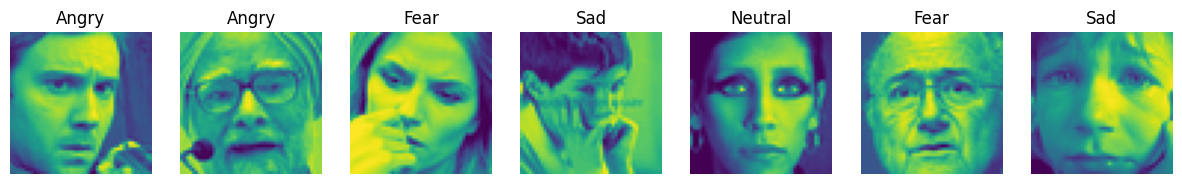

In [7]:
plt.figure(figsize=(15,23))
i = 1
for i in range (7):
    img = np.squeeze(X_train[i])
    plt.subplot(1,7,i+1)
    plt.imshow(img)
    index = np.argmax(y_train[i])
    plt.title(CLASS_LABELS[index])
    plt.axis('off')
    i += 1
plt.show()

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    zoom_range=0.05,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

BATCH_SIZE = 64

train_generator = train_datagen.flow(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_generator = val_datagen.flow(
    X_val, y_val,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_generator = test_datagen.flow(
    X_test, y_test,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [9]:
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation, MaxPooling2D,
    Dropout, GlobalAveragePooling2D, Dense, Add, Multiply,
    Reshape, GlobalMaxPooling2D, Concatenate, Lambda
)
import tensorflow.keras.backend as K

def channel_attention_module(x, reduction_ratio=8):
    """Module CAM - Chú ý theo Kênh"""
    channels = int(x.shape[-1])
    hidden = max(channels // reduction_ratio, 8)
    
    # Shared MLP (Mạng nơ-ron dùng chung cho cả Average và Max pooling)
    shared_1 = Dense(hidden, activation="relu", use_bias=False)
    shared_2 = Dense(channels, use_bias=False)
    
    # Xử lý nhánh Average và Max Pooling
    avg_pool = GlobalAveragePooling2D()(x)
    avg_pool = Reshape((1, 1, channels))(avg_pool)
    avg_pool = shared_2(shared_1(avg_pool))

    max_pool = GlobalMaxPooling2D()(x)
    max_pool = Reshape((1, 1, channels))(max_pool)
    max_pool = shared_2(shared_1(max_pool))
    
    # Cộng 2 nhánh lại và đưa qua hàm Sigmoid để lấy trọng số từ 0 -> 1
    attention = Add()([avg_pool, max_pool])
    attention = Activation("sigmoid")(attention)
    
    # Nhân trọng số attention vào dữ liệu gốc
    return Multiply()([x, attention])

def spatial_attention_module(x):
    """Module SAM - Chú ý theo Không gian"""
    # Ép bẹp dọc theo trục kênh
    avg_pool = Lambda(lambda t: tf.reduce_mean(t, axis=-1, keepdims=True))(x)
    max_pool = Lambda(lambda t: tf.reduce_max(t, axis=-1, keepdims=True))(x)
    
    # Ghép 2 bản đồ 2D lại
    attention = Concatenate(axis=-1)([avg_pool, max_pool])
    
    # Dùng Conv2D với kernel 7x7 để tìm kiếm vùng không gian quan trọng (Mắt, Miệng...)
    attention = Conv2D(filters=1, kernel_size=3, padding='same', activation='sigmoid', use_bias=False)(attention)
    
    # Nhân bản đồ không gian vào dữ liệu hiện tại
    return Multiply()([x, attention])

def cbam_block(x, reduction_ratio=8):
    """Khối CBAM hoàn chỉnh: Kết hợp tuần tự CAM -> SAM"""
    x = channel_attention_module(x, reduction_ratio)
    x = spatial_attention_module(x)
    return x

In [10]:
def conv_bn_relu(x, filters, kernel_size=3, dilation_rate=1):
    x = Conv2D(
        filters, kernel_size,
        padding="same",
        dilation_rate=dilation_rate,
        use_bias=False,
        kernel_initializer="he_normal"
    )(x)
    x = BatchNormalization()(x)
    return Activation("relu")(x)

In [11]:
def residual_block(x, filters, dilation_rate=1):
    shortcut = x

    x = conv_bn_relu(x, filters, 3, dilation_rate=dilation_rate)
    x = Conv2D(
        filters, 3, padding="same",
        dilation_rate=dilation_rate,
        use_bias=False,
        kernel_initializer="he_normal"
    )(x)
    x = BatchNormalization()(x)

    if int(shortcut.shape[-1]) != filters:
        shortcut = Conv2D(filters, 1, padding="same", use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    return Activation("relu")(x)

In [12]:
from tensorflow.keras.models import Model

def custom_cnn(input_shape=(48, 48, 1), num_classes=7):
    inputs = Input(shape=input_shape)

    # Block 1: 48x48 -> 24x24
    x = conv_bn_relu(inputs, 64)
    x = conv_bn_relu(x, 64)
    x = MaxPooling2D(pool_size=2)(x)
    x = Dropout(0.20)(x)

    # Block 2: 24x24 -> 12x12
    x = conv_bn_relu(x, 128)
    x = conv_bn_relu(x, 128)
    x = MaxPooling2D(pool_size=2)(x)
    x = Dropout(0.25)(x)

    # Block 3: 12x12
    # Dilated conv giúp lấy ngữ cảnh rộng hơn quanh mắt, miệng, chân mày.
    x = conv_bn_relu(x, 256)
    x = residual_block(x, 256, dilation_rate=2)
    x = cbam_block(x, reduction_ratio=8)
    x = MaxPooling2D(pool_size=2)(x)  # 12x12 -> 6x6
    x = Dropout(0.30)(x)

    # Block 4: 6x6, tăng năng lực biểu diễn nhưng không dùng Flatten.
    x = conv_bn_relu(x, 512)
    x = conv_bn_relu(x, 512)
    x = conv_bn_relu(x, 512)
    x = Dropout(0.40)(x)

    # Classifier
    x = GlobalAveragePooling2D()(x)

    x = Dense(384, use_bias=False, kernel_initializer="he_normal")(x)
    x = BatchNormalization()(x)
    x = Activation("swish")(x)
    x = Dropout(0.50)(x)

    outputs = Dense(num_classes, activation="softmax")(x)

    return Model(inputs, outputs)


model = custom_cnn(input_shape=(48, 48, 1), num_classes=7)
model.summary()

I0000 00:00:1783748896.171958      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783748896.174590      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 48, 48,    │        576 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 48, 48,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 48, 48,    │     36,864 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 24, 24,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 24, 24,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 24, 24,    │     73,728 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 24, 24,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 24, 24,    │    147,456 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 24, 24,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 12, 12,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 12, 12,    │          0 │ max_pooling2d_1[

 Total params: 7,859,417 (29.98 MB)

 Trainable params: 7,853,273 (29.96 MB)

 Non-trainable params: 6,144 (24.00 KB)

In [13]:
class_weight_dict = {
    0: 1.0,   # Anger
    1: 1.2,   # Disgust
    2: 1.15,  # Fear
    3: 0.9,   # Happy
    4: 1.05,  # Sadness
    5: 1.0,   # Surprise
    6: 1.0    # Neutral
}

In [14]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

mcp = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

es = EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

lrd = ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=2e-5,
    verbose=1
)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",                               
    metrics=["accuracy"]
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=40,
    class_weight=class_weight_dict,
    callbacks=[mcp, es, lrd],
    verbose=1
)

Epoch 1/40
  2/449 ━━━━━━━━━━━━━━━━━━━━ 33s 75ms/step - accuracy: 0.1836 - loss: 2.4431   

I0000 00:00:1783748919.303584     134 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.2319 - loss: 2.0363
Epoch 1: val_accuracy improved from None to 0.36473, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 65s 98ms/step - accuracy: 0.2782 - loss: 1.9068 - val_accuracy: 0.3647 - val_loss: 2.2701 - learning_rate: 0.0010
Epoch 2/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.3987 - loss: 1.6172
Epoch 2: val_accuracy improved from 0.36473 to 0.47200, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 30s 66ms/step - accuracy: 0.4301 - loss: 1.5367 - val_accuracy: 0.4720 - val_loss: 1.3600 - learning_rate: 0.0010
Epoch 3/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4921 - loss: 1.3762
Epoch 3: val_accuracy did not improve from 0.47200
449/449 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.4967 - loss: 1.3581 - val_accuracy: 0.4152 - val_loss: 1.5227 - learning_rate

57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step
              precision    recall  f1-score   support

       Angry       0.64      0.61      0.63       491
     Disgust       0.76      0.69      0.72        55
        Fear       0.60      0.50      0.54       528
       Happy       0.90      0.87      0.89       879
         Sad       0.57      0.53      0.55       594
    Surprise       0.80      0.82      0.81       416
     Neutral       0.60      0.76      0.67       626

    accuracy                           0.70      3589
   macro avg       0.69      0.68      0.69      3589
weighted avg       0.70      0.70      0.69      3589



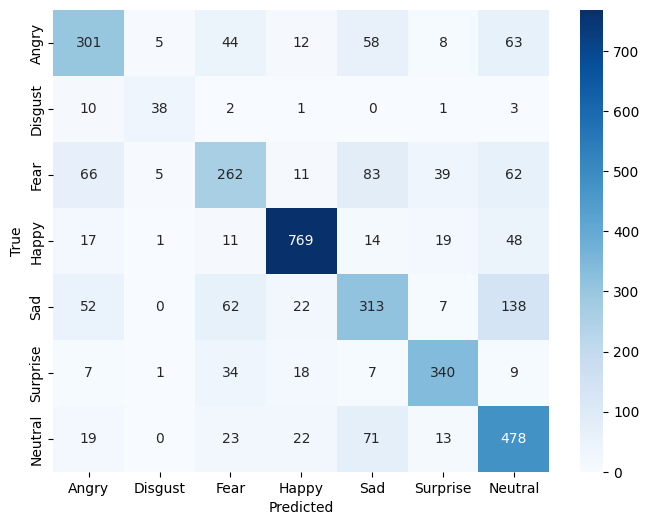

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.load_weights("best_model.keras")

y_prob = model.predict(test_generator)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

target_names = [CLASS_LABELS[i] for i in range(NUM_CLASSES)]

print(classification_report(y_true, y_pred, target_names=target_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

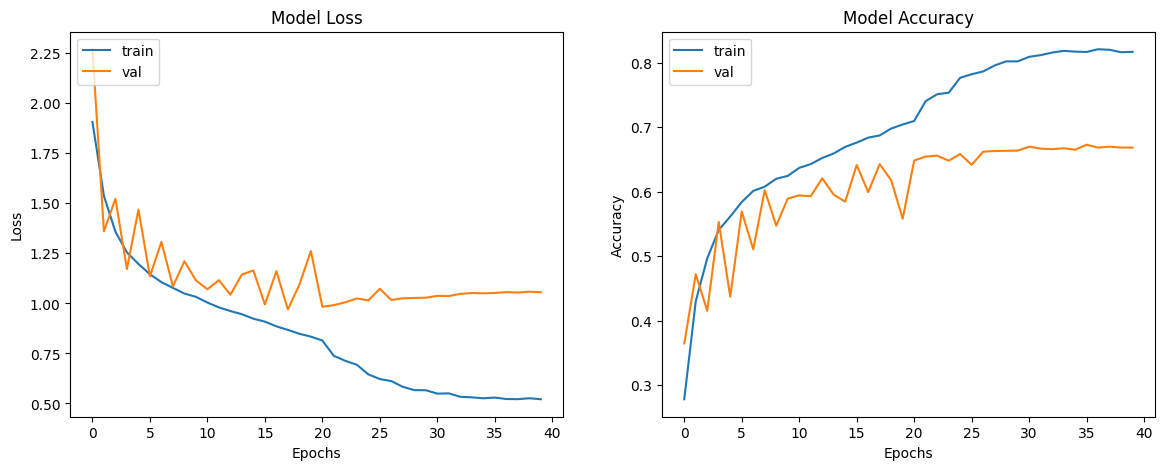

In [16]:
from tensorflow.keras.utils import plot_model

plt.figure(figsize=(14,5))

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['train', 'val'], loc='upper left')

# Loss plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['train', 'val'], loc='upper left')

plt.show()

In [17]:
import json

SAVE_PATH = "/kaggle/working/best_model.keras"

model.save(SAVE_PATH)

with open("/kaggle/working/class_labels.json", "w") as f:
    json.dump(CLASS_LABELS, f)

print("Đã lưu:", SAVE_PATH)

Đã lưu: /kaggle/working/best_model.keras
